# Predicción del precio de vuelos

## Objetivo
Desarrollar modelos lineales que permitan predecir el precio de vuelos y evaluar su capacidad de generalización.

## Descripción del dataset
Breve explicación de las variables disponibles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('precio_vuelos_tr.csv', encoding='latin1')
#Le agregamos el encoding='latin1' porque al parecer por las tildes tiraba error

Index(['index', 'airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

## 1. Exploración inicial de datos

In [ ]:
df.columns

In [ ]:
df.head(20)

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
1,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
2,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
3,5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
4,6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
5,7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
6,8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
7,9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954
8,11,GO_FIRST,G8-338,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5954
9,12,Indigo,6E-5001,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5955


De esta parte podemo obsveras a priori que hay variables que no son relevantes como "index" y "flight"

Para las demas verificaremos si hay alguna relacion que podamos notar visualmente

In [ ]:
# Verificamos nulos y tipos de datos
print(df.isnull().sum())
df.info()

index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240123 entries, 0 to 240122
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             240123 non-null  int64  
 1   airline           240123 non-null  object 
 2   flight            240123 non-null  object 
 3   source_city       240123 non-null  object 
 4   departure_time    240123 non-null  object 
 5   stops             240123 non-null  object 
 6   arrival_time      240123 non-null  object 
 7   destination_city  240123 non-null  object 
 8   class             240123 non-null  object 
 9   duration          240123 non-null  float64
 10  days_left         240123 non-nu

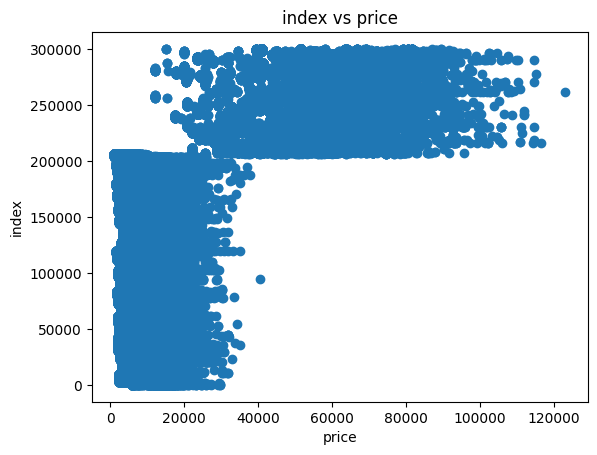

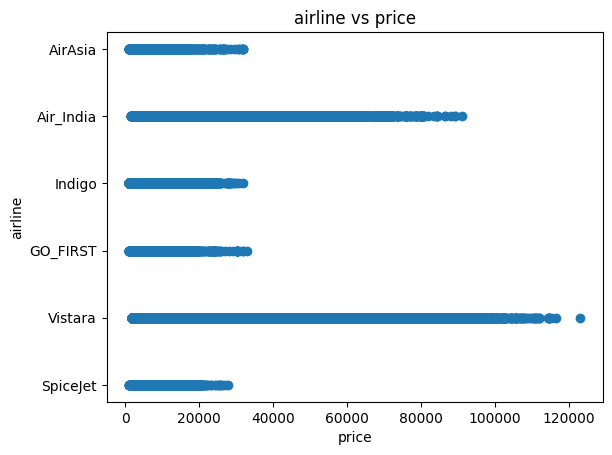

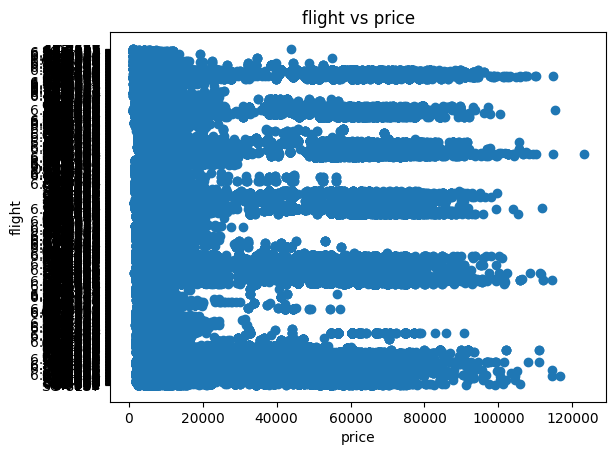

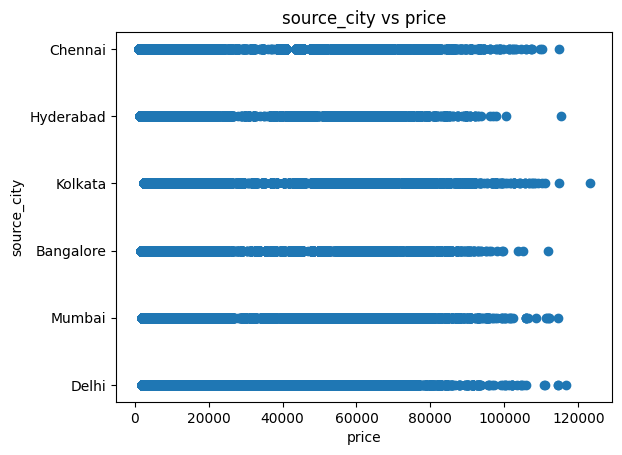

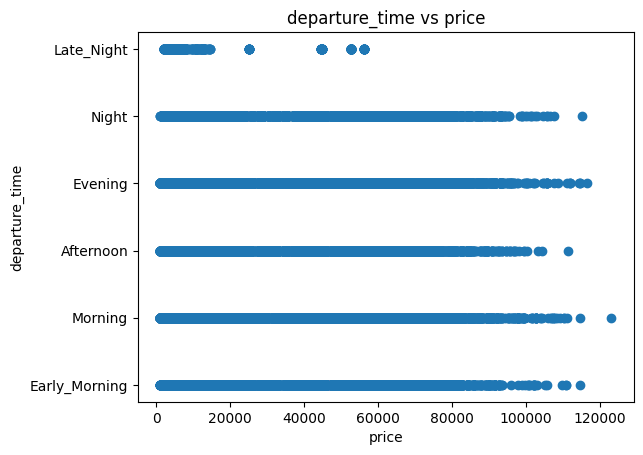

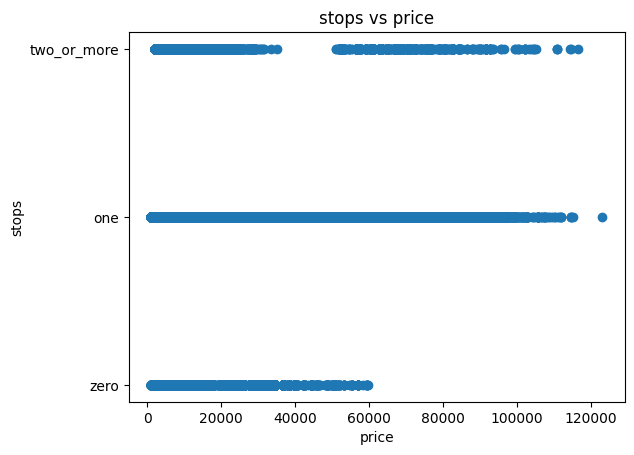

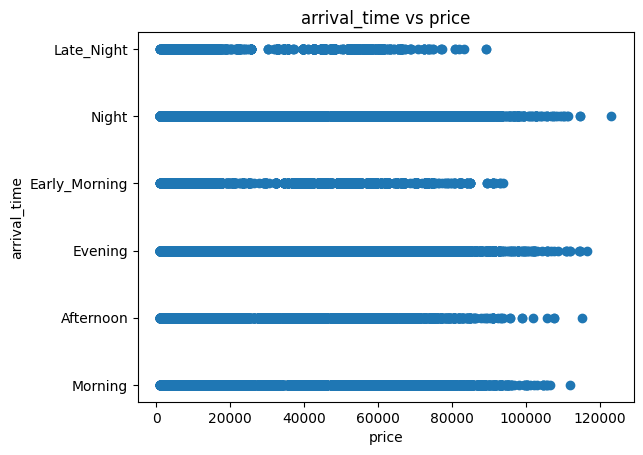

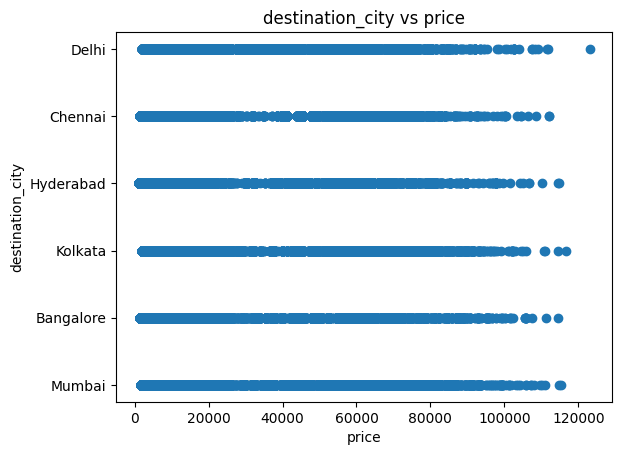

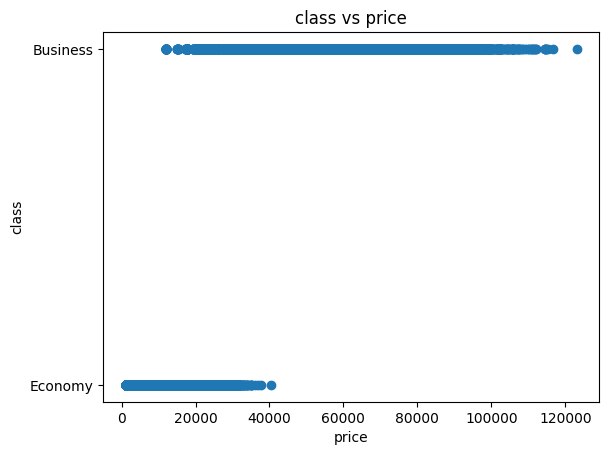

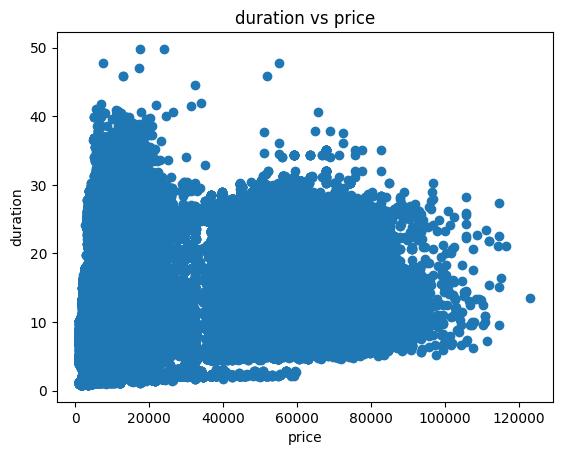

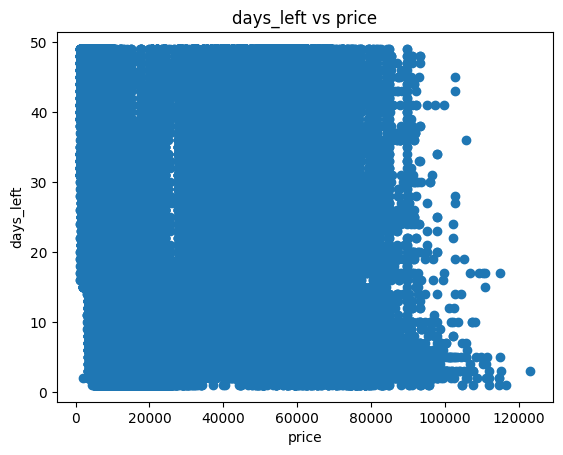

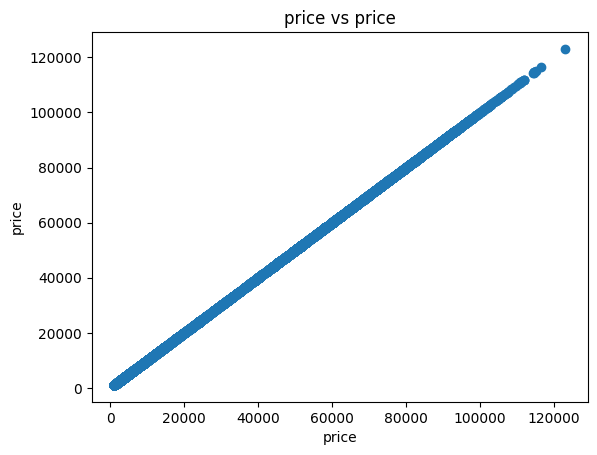

In [ ]:
for col in df:
  plt.scatter(df['price'],df[col])
  plt.xlabel('price')
  plt.ylabel(col)
  plt.title(f'{col} vs price')
  plt.show()


## 2. Análisis exploratorio


Para las variables podemos ver :

En Aerolinia podemos observer diferencias entre aerolineas y el precio de los vuelos siendo que hay aerolinias que no superan una cantidad en sus precios y otras que van desde 0 hasta los 120000

Para Ciudad de destino y ciudad de salida observamos que hay una distribucion pareja con sus precios por lo que parece indicar que no son tan relevantes como para ser la variable mas fuerte en una regresion de una sola variable pero no vamos a descartarla para la mutilineal

Para el tiempo de salida  el tiempo de aterrizaje que la categoria late night tienede a tener una relacion con los precios bajos, pero siguen sin ser variables fuertes para una regresion lineal

Para la variable Clase es donde observamos lo mas interesante, una fuerte division de precios entre la classe economica y la bussines

En la variable de duracion se ve que hay hay vuelos cortos con precios altos y bajos como vuelos largos con precios altos y tambien bajos , asi que no parece ser una variable importante ni para el modelo lineal ni el multilineal

Un caso similar al anterior es el de la variable de dias restantes para el vuelo


Ahora veremos de manera mas directa cuantas categorias tenemos en cada variable cualitativa, obviando las que ya son cuantitativas y a las que sacaremos por ser irrelevantes

In [ ]:
for col in df:
  if col in {'index', 'flight','price','days_left','duration'}:
    continue
  print(f"Variable: {col}-------------------------------------")
  n_origen = df[col].nunique()
  print(f"Hay {n_origen} categorias unicas.")
  print("Lista de categorias:")
  print(df[col].unique())
  #print("\nDistribución de categorias :")
  #print(df[col].value_counts())


Variable: airline-------------------------------------
Hay 6 categorias unicas.
Lista de categorias:
['SpiceJet' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India' 'AirAsia']
Variable: source_city-------------------------------------
Hay 6 categorias unicas.
Lista de categorias:
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
Variable: departure_time-------------------------------------
Hay 6 categorias unicas.
Lista de categorias:
['Early_Morning' 'Morning' 'Afternoon' 'Evening' 'Night' 'Late_Night']
Variable: stops-------------------------------------
Hay 3 categorias unicas.
Lista de categorias:
['zero' 'one' 'two_or_more']
Variable: arrival_time-------------------------------------
Hay 6 categorias unicas.
Lista de categorias:
['Morning' 'Afternoon' 'Evening' 'Early_Morning' 'Night' 'Late_Night']
Variable: destination_city-------------------------------------
Hay 6 categorias unicas.
Lista de categorias:
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
Variable:

## 3. Preprocesamiento de datos

In [ ]:
# Eliminamos las columnas especificando los nombres en una lista
# axis=1 indica que estamos borrando columnas (no filas)
df = df.drop(['index', 'flight'], axis=1)

# Verificamos que ya no estén
print(df.columns)

Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class', 'duration', 'days_left', 'price'],
      dtype='object')


In [ ]:
df.head(20)

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
1,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
2,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
5,Vistara,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
6,GO_FIRST,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
7,GO_FIRST,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954
8,GO_FIRST,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5954
9,Indigo,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5955


Ahora convertiremos nuestras variables cualitativas a dicótomicas recordando los que nos indican en el capitulo 9 del libro usando m-1 columnas por cada m categorias en cada variable  

In [ ]:
# Lista de variables categóricas a convertir
variables_categoricas = [
    'airline', 'source_city', 'departure_time',
    'stops', 'arrival_time', 'destination_city', 'class'
]

# Creamos las variables dicotómicas
# drop_first=True elimina la primera categoría de cada variable (n-1)
df = pd.get_dummies(df, columns=variables_categoricas, drop_first=True, dtype=int)
#el dtype=int hacer que las variables sean 0 y 1 y no True y Flase

In [ ]:
df.head(20)

,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,2.33,1,5953,0,0,0,1,0,0,1,...,0,0,1,0,0,0,0,0,1,1
1,2.25,1,5955,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,1,1
2,2.33,1,5955,0,0,0,0,1,0,1,...,0,0,1,0,0,0,0,0,1,1
3,2.33,1,5955,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,1,1
4,2.08,1,6060,0,0,0,0,1,0,1,...,0,0,1,0,0,0,0,0,1,1
5,2.17,1,6060,0,0,0,0,1,0,1,...,1,0,0,0,0,0,0,0,1,1
6,2.17,1,5954,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,1,1
7,2.25,1,5954,0,1,0,0,0,0,1,...,1,0,0,0,0,0,0,0,1,1
8,2.33,1,5954,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
9,2.17,1,5955,0,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,1,1


## 4. Particion de Datos, entrenamiento y prueba

Ahora que tenemos nuestro data liso limpio haremos una particion para entrenar nuestro modelo y otro para probarlo

In [ ]:
# Definimos X y Y
X = df.drop('price', axis=1)
Y = df['price']

# Particionamos el dataset en 2 grupos, uno para el entrenamiento del modelo y el otro para la prueba del modelo
# random_state=27 para que la división sea la misma siempre que corra el programa y elijo 27 por ser mi numero favorito
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=27)
#Serapamos en un 20|80 nuestro data
print(f"Data de entrenamiento: {X_train.shape[0]} registros")
print(f"Data de prueba: {X_test.shape[0]} registros")

Data de entrenamiento: 192098 registros
Data de prueba: 48025 registros


## 5. Regresión lineal simple

In [ ]:
# Unimos temporalmente para realizar una matriz de correlacion
train_df = pd.concat([X_train, Y_train], axis=1)
# Calculamos la correlación y nos enfocamos solo en la columna 'price'
correlacion_precio = train_df.corr()['price'].sort_values(ascending=False)

print("--- Correlación de variables con respecto al Precio ---")
print(correlacion_precio)

--- Correlación de variables con respecto al Precio ---
price                           1.000000
airline_Vistara                 0.362006
duration                        0.204285
airline_Air_India               0.069333
arrival_time_Evening            0.056524
departure_time_Night            0.041016
arrival_time_Morning            0.030706
destination_city_Kolkata        0.022255
arrival_time_Night              0.019018
source_city_Chennai             0.018402
destination_city_Chennai        0.018150
departure_time_Morning          0.017823
source_city_Kolkata             0.016944
source_city_Mumbai              0.016291
destination_city_Mumbai         0.007625
departure_time_Evening          0.007437
destination_city_Hyderabad     -0.006896
departure_time_Early_Morning   -0.011525
source_city_Hyderabad          -0.014347
departure_time_Late_Night      -0.032911
source_city_Delhi              -0.043177
destination_city_Delhi         -0.052458
arrival_time_Early_Morning     -0.061257
s

Aqui observamos que la que tiene mayor relacion es class_Economy

Y como comentarios quisiera resaltar las bajas cantidades que tenemos para las variables que son de Paises de destino y llegada , o los tiempos de despegue y aterrizaje

que concuerdan con nuestra intuicion del analisis inicial.

In [ ]:
# Creamos el modelo para la regresión simple
modelo_simple = LinearRegression()

# Entrenamos solo con 'class_Economy'
# Usamos doble corchete para mantener el formato de DataFrame que espera sklearn
modelo_simple.fit(X_train[['class_Economy']], Y_train)


# Realizamos la predicción en el set de prueba
Y_pred_simple = modelo_simple.predict(X_test[['class_Economy']])

# Métricas del inciso 1
r2_s = modelo_simple.score(X_test[['class_Economy']], Y_test)
mae_s = mean_absolute_error(Y_test, Y_pred_simple)
rmse_s = np.sqrt(mean_squared_error(Y_test, Y_pred_simple))
print(f"--- Inciso 1: Mejor Variable Individual (class_Economy) ---")
print(f"R^2 en Test: {r2_s:.4f}")
print(f"Error Absoluto Medio (MAE): {mae_s:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_s:.2f}")
print(f"Ecuación: Precio = {modelo_simple.intercept_:.2f} + ({modelo_simple.coef_[0]:.2f} * class_Economy)")

--- Inciso 1: Mejor Variable Individual (class_Economy) ---
R^2 en Test: 0.8832
Error Absoluto Medio (MAE): 4876.46
Raíz del Error Cuadrático Medio (RMSE): 7794.63
Ecuación: Precio = 52511.86 + (-45940.37 * class_Economy)


Vemos que nuestro R cuadrado es del 0.88 lo cual es bastante aceptable.

Nuestro error absoluto con respecto a Y_test, o sea, a la particion que hicimos para evaluar nuestro modelo es de 4876.46

Ahora realicemos nuestro modelo multilineal incluyendo todas las variables

## 6. Regresión lineal múltiple

In [ ]:
#Definir X (todas menos el precio) e y (el precio)
X_multi = train_df.drop('price', axis=1)
y_multi = train_df['price']

#Crear y entrenar el modelo multilineal
modelo_final = LinearRegression()
modelo_final.fit(X_train, Y_train)

#Predecir
y_pred = modelo_final.predict(X_test)

r2_final = modelo_final.score(X_test, Y_test)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))

print("--- RESULTADOS MODELO MULTILINEAL ---")
print(f"R^2 en Test: {r2_final:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

--- RESULTADOS MODELO MULTILINEAL ---
R^2 en Test: 0.9137
Error Absoluto Medio (MAE): 4563.17
Raíz del Error Cuadrático Medio (RMSE): 6702.56


Observamos una mejora considerable de aproximadamente entre 3% y 4%.
y un MAE y un RMSE menores respecto al modelo lineal

## 7. Validación del modelo

### 7.1. Regresion Lineal



Para nuestra regresion lineal tenemos :
R^2 en Test: 0.8832 \
Error Absoluto Medio (MAE): 4876.46 \
Raíz del Error Cuadrático Medio (RMSE): 7794.63 \
Ecuación: Precio = 52511.86 + (-45940.37 * class_Economy) \

Observamos que este modelo se acerca un 88% a nuestros datos de Y_Prueba \
Por lo que podemos concluir que nuestro modelo si predice, no solo memoriza el comportamiento de nuestro X_test. \
Siendo una variable Dicótomica , tenemos solo dos valores posibles de predicción,



### 7.2. Regresion Multilineal

Nuestra regresion multilineal nos da los resultados : \
R^2 en Test: 0.9137 \
Error Absoluto Medio (MAE): 4563.17 \
Raíz del Error Cuadrático Medio (RMSE): 6702.56 \

Una mejora de aproximadamente un 4%.
Con un castigo menor para valores altos, como observamos en el RMSE


## 8. Reducción de dimensionalidad (PCA)

Antes de registrar nuestro modelo multilineal haremos una prueba de reduccion de dimensionalidad para vertificar si podemos reducir los datos sin tanta perdida de informacion

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Creamos un DataFrame para mostrar los resultados
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train.columns

# Calculamos el VIF para cada columna
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i)
                   for i in range(len(X_train.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                        Variable       VIF
6                airline_Vistara  7.192338
0                       duration  6.892415
2              airline_Air_India  5.258830
1                      days_left  4.354775
29                 class_Economy  3.759707
23            arrival_time_Night  3.092272
4                 airline_Indigo  2.881604
20          arrival_time_Evening  2.823856
22          arrival_time_Morning  2.565235
13        departure_time_Evening  2.389887
15        departure_time_Morning  2.360103
12  departure_time_Early_Morning  2.272014
11            source_city_Mumbai  2.141340
28       destination_city_Mumbai  2.135555
8              source_city_Delhi  2.108442
25        destination_city_Delhi  2.085934
16          departure_time_Night  2.072997
3               airline_GO_FIRST  2.012968
27      destination_city_Kolkata  1.954996
10           source_city_Kolkata  1.857891
26    destination_city_Hyderabad  1.823961
24      destination_city_Chennai  1.791376
9          

Con esto observamos que cada variable en comparacion con el conjunto de las demas no supera el 90% de ser explicadas por las demas, por lo que podemos considerar conservar todas

Por otro lado , considerando poder hacer una reduccion de dimensionalidad, observo que no es necesario ya que nuestro modelo ya predice en un 90% .

De igual manera ejecutaremos la idea usando la tecnica de componente principales PCA y veremos por donde queda nuestro "codo"

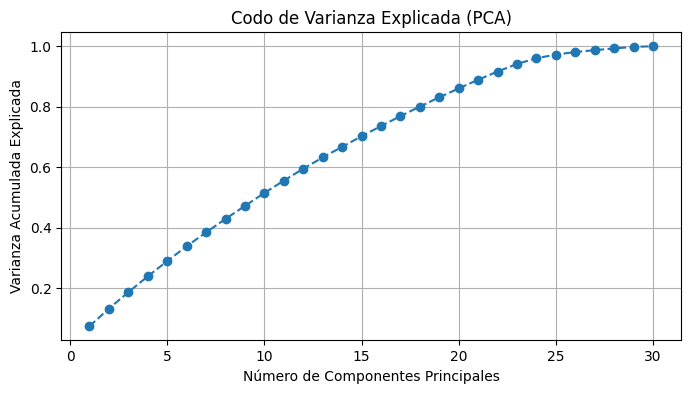

In [ ]:


#Estandarizamos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

#Aplicamos PCA
pca = PCA()
pca.fit(X_train_scaled)

#Calculamos la varianza acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

#Graficamos
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('Codo de Varianza Explicada (PCA)')
plt.grid(True)
plt.show()

Observamos que nuestro codo esta muy por la derecha, de manera visual, vemos el codo aproximadamente por el 25, o sea que 25 componentes explican mas del 95% (visualmente) por lo que no veo necesidad de eliminar tan pocas variables.

Ademas de que perderiamos informacion interpretable, podriamos predecir el precio pero no sabriamos que cosas influyen directamente en el precio (como la clase del vuelo, etc.)

## 9. Comparacion de Resultados


In [2]:
data_comp = {
    "Métrica": ["R2", "MAE", "RMSE"],
    "Modelo Simple": [0.8832, 4876.46, 7794.63],
    "Modelo Multilineal": [0.9137, 4563.17, 6702.56],
    "¿Cuál es mejor?": [
        "Multilineal (Explica más)",
        "Multilineal (Menos error promedio)",
        "Multilineal (Menos errores grandes)"
    ]
}

df = pd.DataFrame(data_comp)

df

,Métrica,Modelo Simple,Modelo Multilineal,¿Cuál es mejor?
0,R2,0.8832,0.9137,Multilineal (Explica más)
1,MAE,4876.4600,4563.1700,Multilineal (Menos error promedio)
2,RMSE,7794.6300,6702.5600,Multilineal (Menos errores grandes)


El modelo multilineal es superior en todos los frentes. Redujo el error promedio en unas 300 unidades e hizo que el modelo sea mucho más estable (reducción fuerte del RMSE).

Guardaremos el modelo

In [ ]:
# Guardamos el modelo
with open('mejor_modelo_vuelos.pkl', 'wb') as archivo_mod:
    pickle.dump(modelo_final, archivo_mod)

# Guardamos la LISTA de columnas que el modelo conoce
columnas_entrenamiento = X_train.columns.tolist()
with open('columnas_modelo.pkl', 'wb') as archivo_col:
    pickle.dump(columnas_entrenamiento, archivo_col)

## 10. Graficas

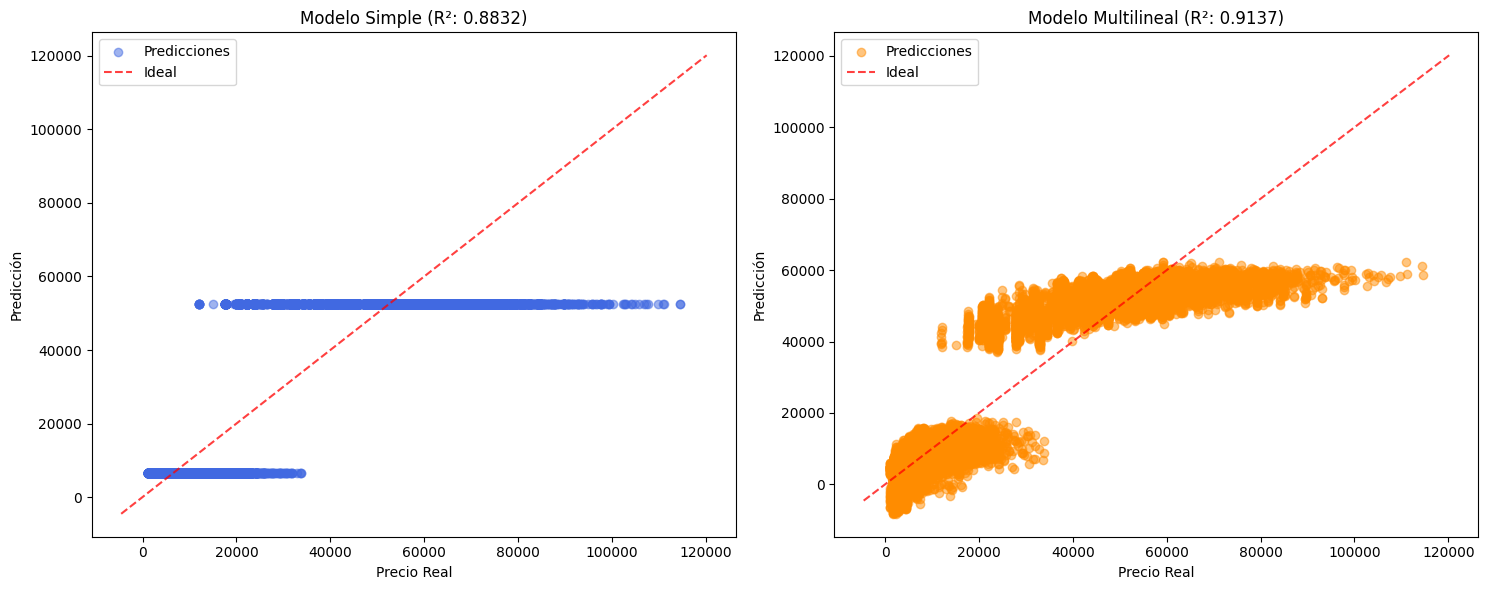

In [ ]:
# Creamos una figura con dos subplots para comparar ambos modelos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Gráfica Modelo Simple ---
ax1.scatter(Y_test, Y_pred_simple, alpha=0.5, color='royalblue', label='Predicciones')
# Línea de 45 grados (Ideal)
lims = [np.min([ax1.get_xlim(), ax1.get_ylim()]), np.max([ax1.get_xlim(), ax1.get_ylim()])]
ax1.plot(lims, lims, 'r--', alpha=0.75, zorder=3, label='Ideal')
ax1.set_title(f'Modelo Simple (R²: 0.8832)')
ax1.set_xlabel('Precio Real')
ax1.set_ylabel('Predicción')
ax1.legend()

# --- Gráfica Modelo Multilineal ---
ax2.scatter(Y_test, y_pred, alpha=0.5, color='darkorange', label='Predicciones')
# Línea de 45 grados (Ideal)
ax2.plot(lims, lims, 'r--', alpha=0.75, zorder=3, label='Ideal')
ax2.set_title(f'Modelo Multilineal (R²: 0.9137)')
ax2.set_xlabel('Precio Real')
ax2.set_ylabel('Predicción')
ax2.legend()

plt.tight_layout()
plt.show()

Se observa que el modelo multilineal (derecha) logra romper la estructura bimodal del modelo simple, capturando la variabilidad interna de las clases mediante la duración y aerolíneas. No obstante, se detecta una tendencia a la subestimación en precios de clase Business (superiores a 60,000) y la presencia de ligeros valores negativos en el extremo inferior, sugiriendo que la relación real podría presentar leves no linealidades o requerir un truncamiento en cero.